# **Project 3**, APS1070 Fall 2022
#### **PCA [14 marks]**
**Deadline: Nov 17, 21:00**

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   **Name**: Sudarsanamurthy Tenneti Prabakaramurthy
*   **Student number**: 1008628601



### How to submit **(HTML + IPYNB)**

1. Download your notebook: `File -> Download .ipynb`

2. Click on the Files icon on the far left menu of Colab

3. Select & upload your `.ipynb` file you just downloaded, and then obtain its path (right click) (you might need to hit the Refresh button before your file shows up)


4. execute the following in a Colab cell:
```
%%shell
jupyter nbconvert --to html /PATH/TO/YOUR/NOTEBOOKFILE.ipynb
```

5. An HTML version of your notebook will appear in the files, so you can download it.

6. Submit **both** <font color='red'>`HTML` and `IPYNB`</font>  files on Quercus for grading.



Ref: https://stackoverflow.com/a/64487858 



In this project we work on a Covid-19 dataset that reports the number of confirmed cases per day and Fashion MNIST.

# Part 1: Getting started [2 Marks]

In [2]:
import pandas as pd
cases_raw = pd.read_csv(
    filepath_or_buffer='https://raw.githubusercontent.com/aps1070-2019/datasets/master/APS_COVID_Jan22.csv',
    index_col=0,
    thousands=','
)

1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your country list as inputs (US, China, Canada, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each day should have a `mean` of zero and a `StD` of 1. **[0.5]**
3. Run the function in `step 1` on the standardized dataset for the `US`, `China`, and `Canada`.   **[0.5]**
4. Discuss the trends in the standardized time-series for the `US`, `Canada`, and `China`. What does it mean if the curve goes up or down (are the number of covid cases negative?) What does the sign of values indicate? **[0.5]** 
**The curves represent the variation of covid cases with time for different countries. The ups and downs in the curve represents the increase and decrease of covid cases respectively. No, the covid cases are not negative. Since we have standardized the dataset, our mean is 0 for the entire dataset and thus the sign of values indicates the covid cases for a particular country with respect to covid cases of all countries. If the sign is negative, it means that on that day for that particular country, its covid cases is less than the mean of covid cases of all countries.**

In [3]:
cases_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, Afghanistan to Zimbabwe
Columns: 733 entries, 2020-01-22 to 2022-01-23
dtypes: int64(733)
memory usage: 1.1+ MB


In [4]:
cases_raw.head()

,2020-01-22,2020-01-23,2020-01-24,2020-01-25,2020-01-26,2020-01-27,2020-01-28,2020-01-29,2020-01-30,2020-01-31,...,2022-01-14,2022-01-15,2022-01-16,2022-01-17,2022-01-18,2022-01-19,2022-01-20,2022-01-21,2022-01-22,2022-01-23
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,158639,158678,158717,158826,158974,159070,159303,159516,159548,159649
Albania,0,0,0,0,0,0,0,0,0,0,...,228777,230940,232637,233654,236486,239129,241512,244182,246412,248070
Algeria,0,0,0,0,0,0,0,0,0,0,...,224979,225484,226057,226749,227559,228918,230470,232325,234536,236670
Andorra,0,0,0,0,0,0,0,0,0,0,...,29888,29888,29888,29888,29888,29888,32201,33025,33025,33025
Angola,0,0,0,0,0,0,0,0,0,0,...,93302,93524,93694,93974,94275,94779,95220,95676,95902,96582


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

country_names= list(cases_raw.index)

def timeseries(df, country):
  
  index=[]
  global country_names

  for i in country:
    index= np.append(index, country_names.index(i))
  
  
  fig,axes= plt.subplots(len(index), figsize=(12,12))
  fig.suptitle('Timeseries graph for different countries')

  for j in range(len(index)):
    axes[j].plot(df[int(index[j]),:])
    axes[j].set(xlabel='Days',ylabel=country_names[int(index[j])])
         
  

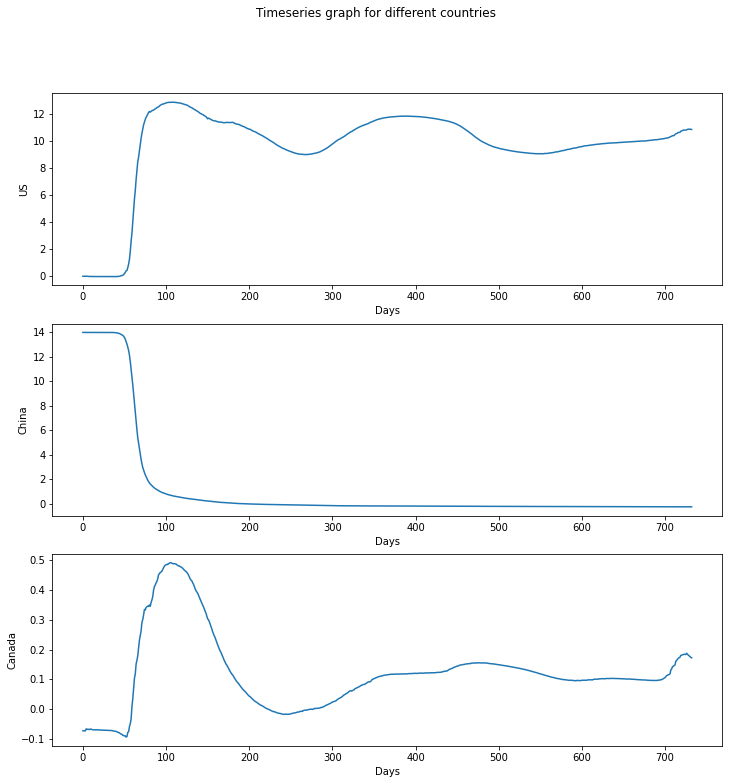

In [6]:
scaler= StandardScaler()
df_std= scaler.fit_transform(cases_raw)
timeseries(df_std,['US','China','Canada'])


# Part 2: Applying PCA [3 Marks]

1. Compute the covariance matrix of the dataframe. *Hint: The dimensions of your covariance matrix should be (733, 733).* **[0.5]**
2. Write a function `get_sorted_eigen(df_cov)` that gets the covariance matrix of dataframe `df` (from step 1), and returns sorted eigenvalues and eigenvectors using `np.linalg.eigh`. **[0.5]**
3. Show the effectiveness of your principal components in covering the variance of the dataset with a `scree plot`(Bars for each componenet and a line to show cumulative --similar to tutoriual. Limit x-axis if needed to better see the plot). **[0.5]**
4. How many PCs do you need to cover 98% of the dataset's variance? **[0.5]** **The minimum number of principal components required to cover 98% of the dataset's variance is 3.**
5. Plot the first 16 principal components (Eigenvectors) as a time series (16 subplots, on the x-axis you have dates and on the y-axis you have the value of the PC element) . **[0.5]**
6. Compare the first few PCs with the rest of them. Do you see any difference in their trend? **[0.5]** **When comparing the first few PCs with the rest of them, we can see that most of the variance associated with the data is captured in the first few eigenvectors itself. Also, we can see that as the eigenvalues decreases, we can see a lot of fluctuations (ups and downs) in the graph in the last few PC's whereas in the first few PC's, the fluctuations were pretty less.**

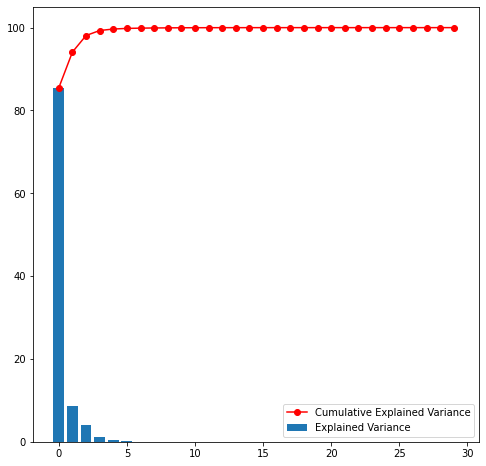

In [7]:
### YOUR CODE HERE ###

df_cov= np.cov(df_std.T)

def get_sorted_eigen(temp_df_cov):
  
  eigenValues, eigenVectors = np.linalg.eigh(temp_df_cov)
  args = (-eigenValues).argsort()
  eigenValues = eigenValues[args]
  eigenVectors = eigenVectors[:, args]
  
  return eigenValues, eigenVectors

eigen_values, eigen_vectors= get_sorted_eigen(df_cov)

eigen_val_sum = sum(eigen_values)
expVar = [(eigV/eigen_val_sum)*100 for eigV in eigen_values]
cumExpVar = np.cumsum(expVar)

plt.figure(figsize=(8,8))
plt.bar(range(30), expVar[:30], label='Explained Variance')
plt.plot(cumExpVar[:30], 'r-o', label='Cumulative Explained Variance')
plt.legend()
plt.show()


In [8]:
pc= np.where(cumExpVar > 98)
print("The minimum number of principal components required to cover 98% of the dataset's variance is:", pc[0][0]+1)

The minimum number of principal components required to cover 98% of the dataset's variance is: 3


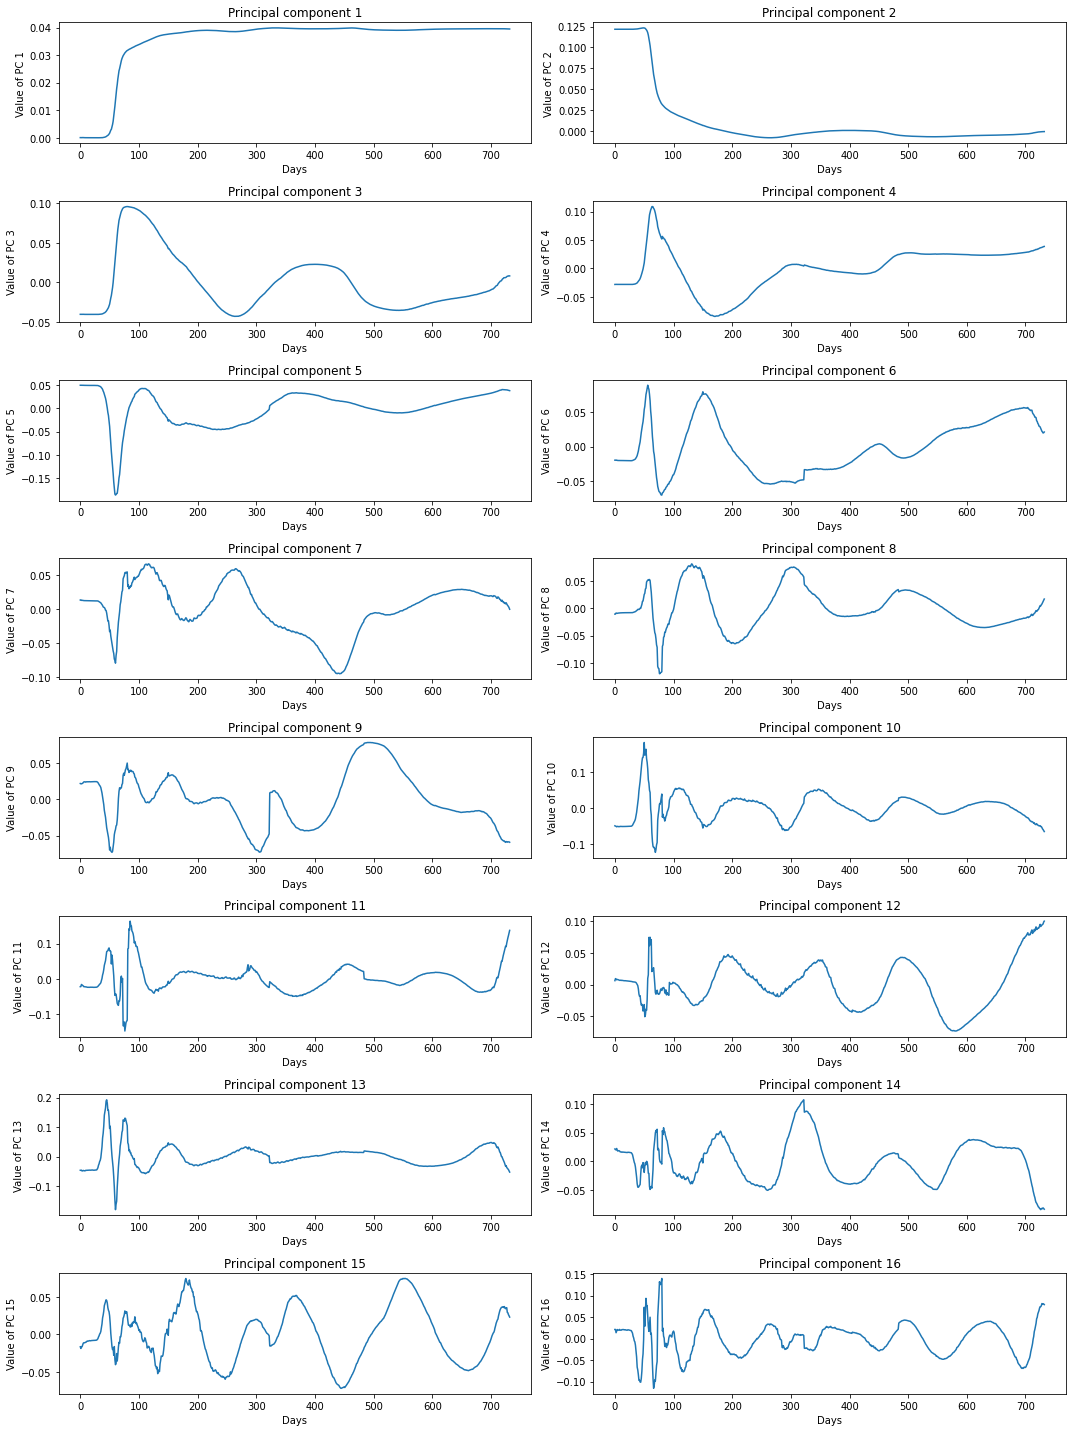

In [9]:
fig,axes = plt.subplots(8,2,figsize=(15,20))

for i in range(16):
  axes.flat[i].plot(eigen_vectors[:,i])
  title_name= 'Principal component '+ str(i+1)
  y_title= 'Value of PC '+ str(i+1)
  axes.flat[i].set(xlabel='Days', ylabel= y_title, title= title_name)

fig.tight_layout()

# Part 3: Data reconstruction [5 Marks]

Create a function that:

*   Accepts a country and the original dataset as inputs.
*   Calls useful functions that you designed in previous parts to compute eigen vectors and eigen values. 
*   Plots 4 figures:
  1.   The original time-series for the specified country. **[1]**
  2.   The incremental reconstruction of the **original** (not standardized) time-series for the specified country in a single plot. **[1]**
       * You should at least show 5 curves in a figure for incremental reconstruction. For example, you can pick the following (or any other combination that you think is reasonable): 
          * Reconstruction with only PC1
          * Reconstruction with both PC1 and PC2
          * Reconstruction with PC1 to PC4 (First 4 PCs)
          * Reconstruction with PC1 to PC8 (First 8 PCs)
          * Reconstruction with PC1 to PC16 (First 16 PCs)

      * Hint: you need to compute the reconstruction for the standardized time-series first, and then scale it back to the original (non-standardized form) using the StandardScaler `inverse_transform` [help...](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.inverse_transform)
  3.   The residual error for your best reconstruction with respect to the original time-series. **[1]**
      * Hint: You are plotting the error that we have for reconstructing each day `(df - df_reconstructed)`. On the x-axis, you have dates, and on the y-axis, the residual error. 
  4.   The RMSE of the reconstruction as a function of the number of included components (x-axis is the number of components and y-axis is the RMSE). Sweep x-axis from 1 to 100 (this part is independent from part 3.2.) **[1]**

Test your function using the `US`, `Canada`, and `China` as inputs. **[1]**


In [10]:
from sklearn.metrics import mean_squared_error

def project (W , proj_df_std):
  return np.dot (proj_df_std, W)

def reconstruct (W , recon_df_std):
  return np.dot (recon_df_std, W.T)

def plot_country_figures(original_df, country_name):

  original_df_std= scaler.fit_transform(original_df)
  original_df_cov= np.cov(original_df_std.T)
  eig_val, eig_vec= get_sorted_eigen(original_df_cov)

  country_index= int(country_names.index(country_name))

  fig,axes= plt.subplots(2,2,figsize=(20,15))
  title_1= str('Original timeseries for ' + country_name)
  axes[0,0].plot(original_df.values[country_index,:])
  axes[0,0].set(xlabel='Days', title= title_1 )

  ###Reconstruct with only PC1###
  
  recon_eigen_vec1= eig_vec[:,0:1]
  project1= project(recon_eigen_vec1, original_df_std)
  reconstruct1= reconstruct(recon_eigen_vec1, project1)
  final_reconstruct1= scaler.inverse_transform(reconstruct1)
  axes[0,1].plot(final_reconstruct1[country_index,:],label='PC1', color='red')
  axes[0,1].set(xlabel='Days',title='Reconstruction of original data with different combination of PCs')

  ###Reconstruct with both PC1 and PC2###
  
  recon_eigen_vec2= eig_vec[:,0:2] 
  project2= project(recon_eigen_vec2, original_df_std)
  reconstruct2= reconstruct(recon_eigen_vec2, project2)
  final_reconstruct2= scaler.inverse_transform(reconstruct2)
  axes[0,1].plot(final_reconstruct2[country_index,:],label='PC1 & PC2', color='blue')
  axes[0,1].set(xlabel='Days',title='Reconstruction of original data with different combination of PCs')

  ###Reconstruct with PC1 to PC4###
  
  recon_eigen_vec3= eig_vec[:,0:4] 
  project3= project(recon_eigen_vec3, original_df_std)
  reconstruct3= reconstruct(recon_eigen_vec3, project3)
  final_reconstruct3= scaler.inverse_transform(reconstruct3)
  axes[0,1].plot(final_reconstruct3[country_index,:],label='PC1 to PC4', color='green')
  axes[0,1].set(xlabel='Days',title='Reconstruction of original data with different combination of PCs')

  ###Reconstruct with PC1 to PC8###
  
  recon_eigen_vec4= eig_vec[:,0:8] 
  project4= project(recon_eigen_vec4, original_df_std)
  reconstruct4= reconstruct(recon_eigen_vec4, project4)
  final_reconstruct4= scaler.inverse_transform(reconstruct4)
  axes[0,1].plot(final_reconstruct4[country_index,:],label='PC1 to PC8', color='purple')
  axes[0,1].set(xlabel='Days',title='Reconstruction of original data with different combination of PCs')

  ###Reconstruct with PC1 to PC16###
  
  recon_eigen_vec5= eig_vec[:,0:16] 
  project5= project(recon_eigen_vec5, original_df_std)
  reconstruct5= reconstruct(recon_eigen_vec5, project5)
  final_reconstruct5= scaler.inverse_transform(reconstruct5)
  axes[0,1].plot(final_reconstruct5[country_index,:],label='PC1 to PC16', color='orange')
  axes[0,1].set(xlabel='Days',title='Reconstruction of original data with different combination of PCs')

  axes[0,1].legend()

  ###Residual error plot###

  ###Reconstruction of data using PC1 to PC8 and PC1 to PC16 were almost similar to that of the original data. Thus, out of the two, we'll choose the model 
  ###reconstructed using PC1 to PC16 for calculating residual error.

  residual_error= original_df.values[country_index,:] - final_reconstruct5[country_index,:]
  axes[1,0].plot(residual_error, color='purple')
  axes[1,0].set(xlabel='Days', ylabel= 'Residual Error', title='Residual error for the reconstruction made using PC1 to PC16')

  ###Root Mean Squared Error plot###

  rmse_list=[]
  
  for i in range(0,100,1):
    W= eig_vec[:, 0:i]
    proj_rmse= np.dot(original_df_std, W)
    recon_rmse= np.dot(proj_rmse, W.T)
    final_recon_rmse= scaler.inverse_transform(recon_rmse)
    mse= mean_squared_error(original_df.values[country_index,:], final_recon_rmse[country_index,:])
    rmse= np.sqrt(mse)
    rmse_list= np.append(rmse_list, rmse)
  
  axes[1,1].plot(rmse_list, color='red')
  axes[1,1].set(xlabel='Number of Principal Components', ylabel='RMSE', title='Root mean squared error as a function of number of principal components included')

  
  fig.tight_layout()


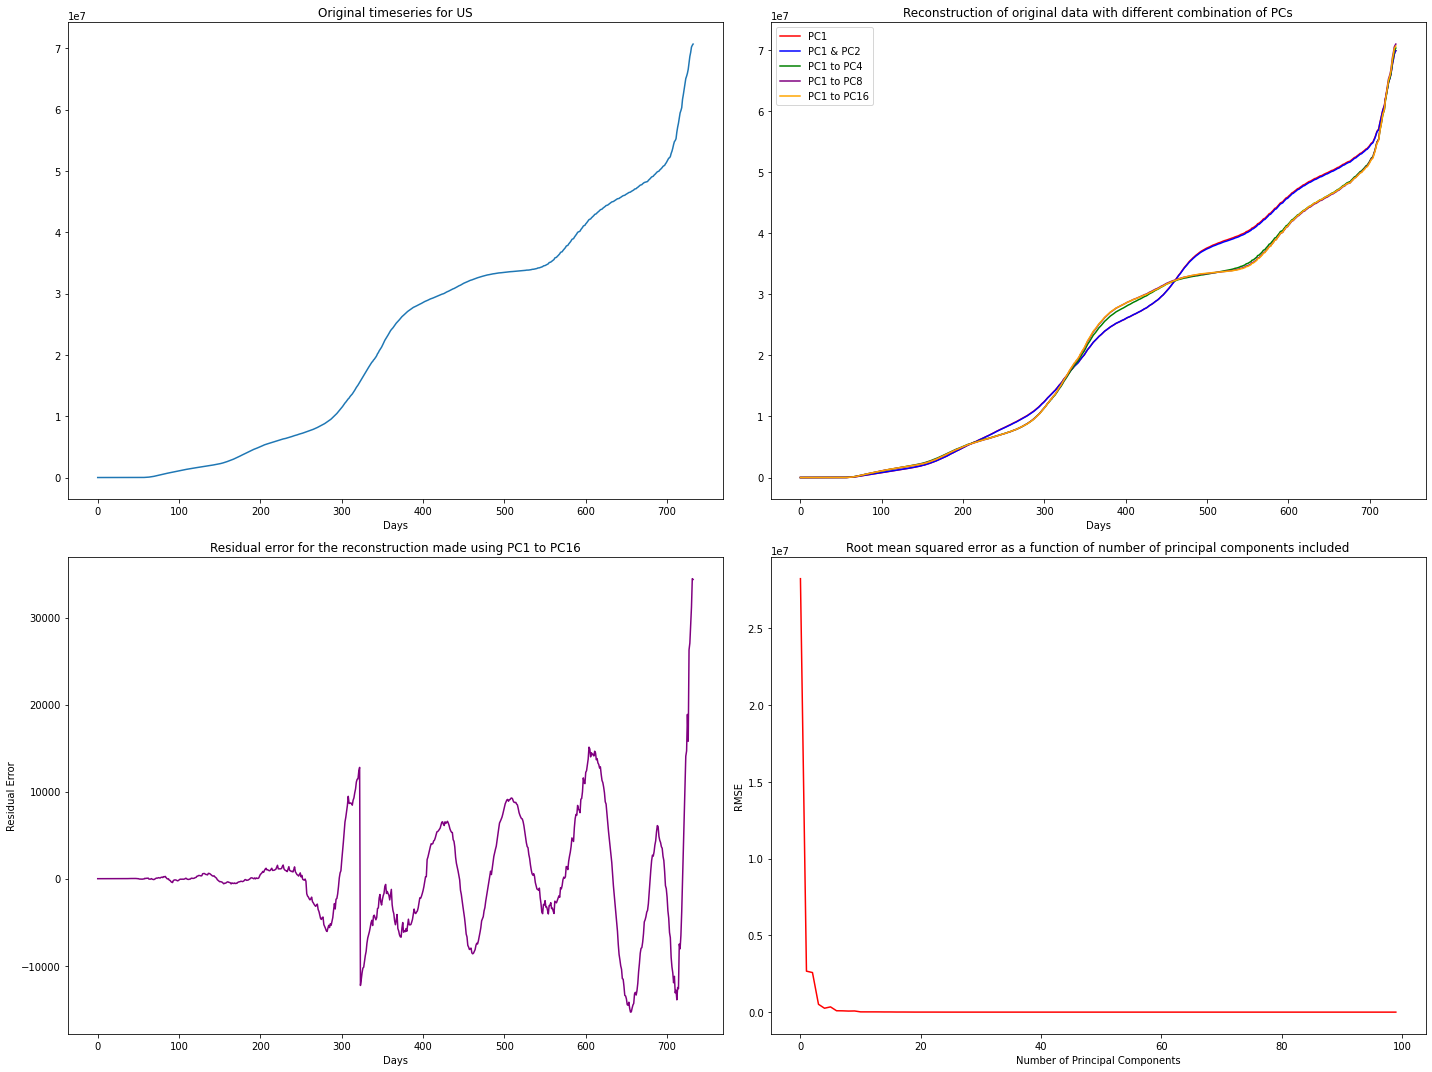

In [11]:
plot_country_figures(cases_raw, 'US')

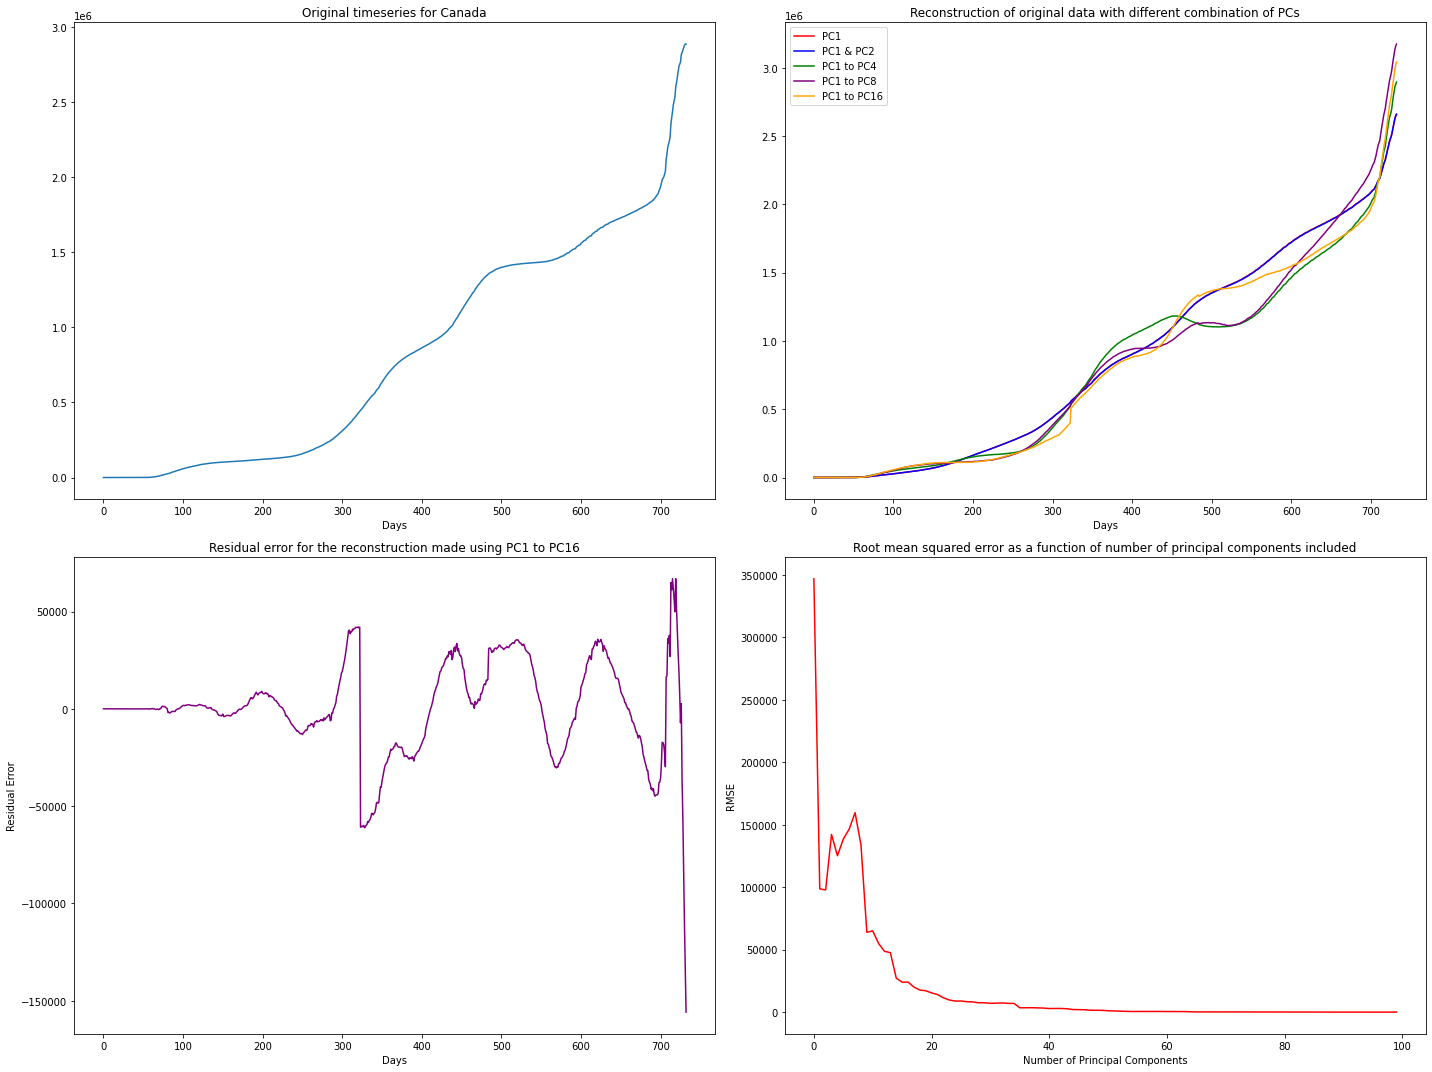

In [12]:
plot_country_figures(cases_raw, 'Canada')

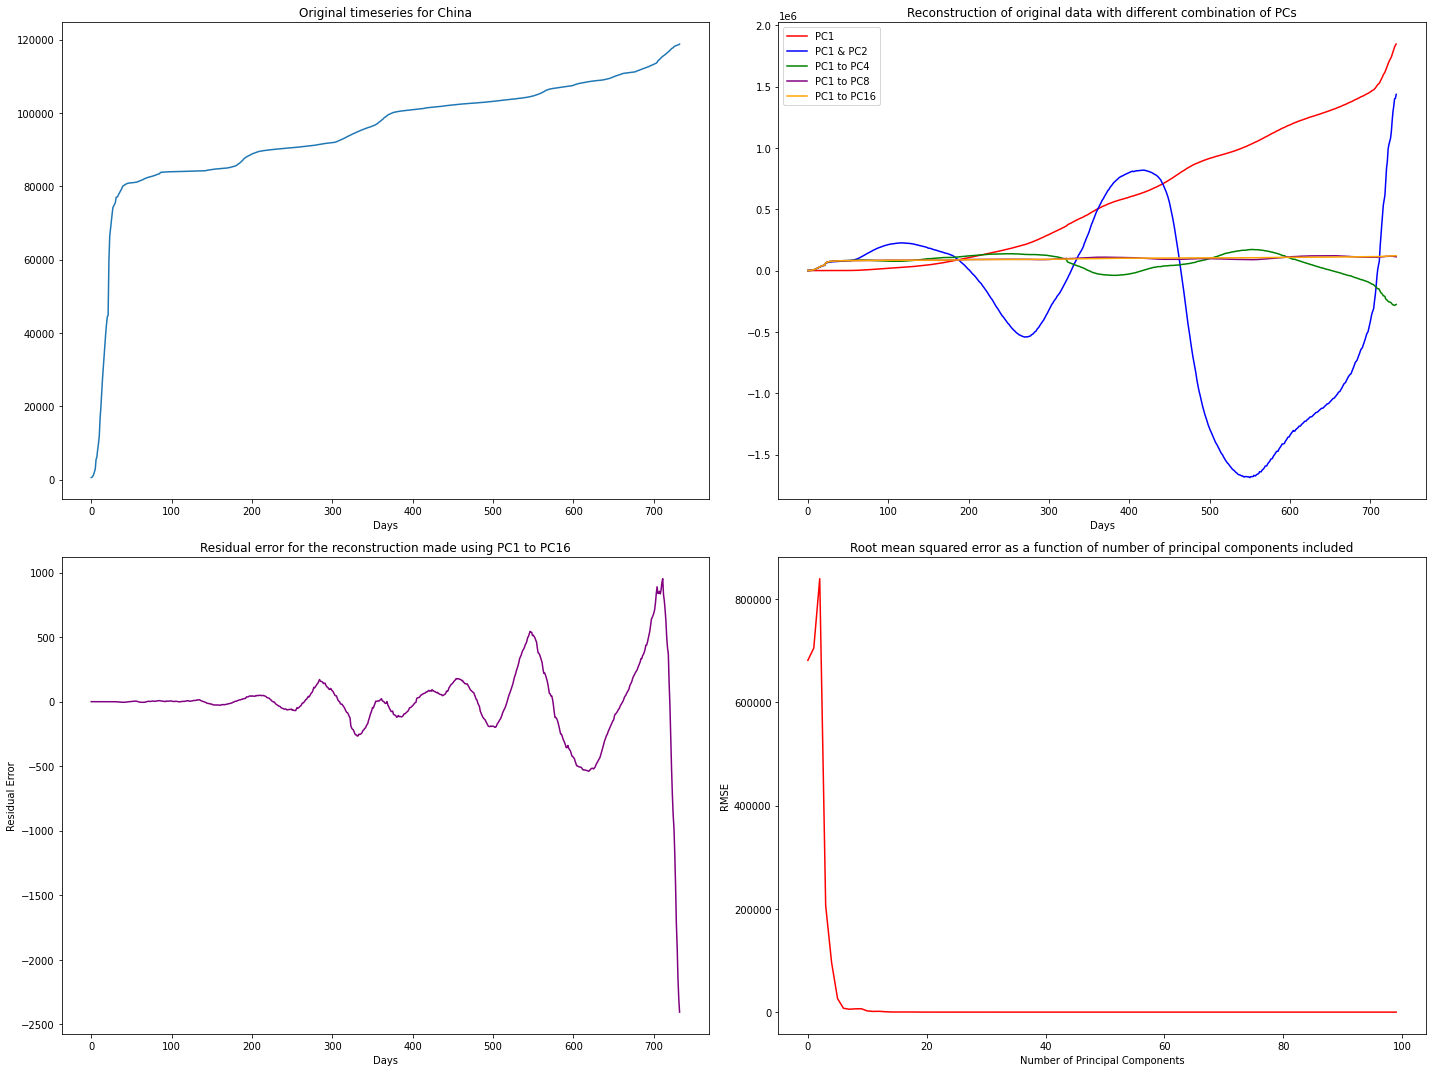

In [13]:
plot_country_figures(cases_raw, 'China')

# Part 4: Fashion-MNIST dataset [4 Marks]
Fashion-MNIST is a dataset for clothes. 
Each image in Fashion-MNIST has 28x28 pixels which can be represented in an array with 784 elements. You can take a better look at this dataset in this [link](https://www.openml.org/d/40996) 

In this part, we are going to use PCA to compress these images. The $x$ matrix below has 1000 images.
* Create a new dataset by selecting images from *only* three categories (three distinct labels). 
    * To compress and reconstruct images better with PCA, it is better to choose items that are similar in shape. why? **[0.5]** **It is better to choose images that are similar in shape as the pixel values associated with similar images would also be more or less similar and thereby it would be simpler for PCA to capture most of the important data in the initial principal components itself and thereby making the compression and reconstructing the images can be done using minimum number of PC's. If images that are dissimilar are chosen then we would require a lot of PC's to capture the major data and thus the compressing as well as reconstructing the images would require greater PC's and thereby diminishing the use of PCA model.**
* Compute Eigenvectors and Eigenvalues. **[0.5]**
* Plot the first 10 eigenvectors (as images similar to eigenfaces). What trends do you observe? **[0.5]** **We can see that most of major data (major variance) that is associated in identifying what image it represents is captured in the first few eigenvectors itself and then the last few eigenvectors contain more noise and they contribute only a little bit to the variance of the data.**
* Create a function that requires an argument $n$ and plots a random image from the dataset, as well as a reconstruction with the first $n$ th principal components. **[1]**
* Run your function a few times, and determine how many components are required so that we (humans!) can identify the items. **[0.5]** **After running the function a few times, on average about 21 principal components are required to identify the items for us humans.**
* Assume you want to share this dataset with someone else. Instead of directly giving them the whole dataset, you can share the eigenvectors (some of them) and projections with them, and thay can do a dot product to get the reconstructions.  Based on the number of components that you found in the last step, what would be the compression ratio for a dataset with 1000 images? **[1]**
  * Hint: compare the dataset size with a case where we only use some principal components and projections.


For our new dataset, its size is (299,784). Thus, the total elements= 234,416.

From the previous step, we see that on average 21 PCs are required to identify the items. Thus, the W_op after applying PCA and selecting the number of PC's is: (784,21).

Now, we apply projection and we get the projection matrix to be as follows:
Proj matrix= New dataset @ W_op= (299,21).

The data is now summarized in W_op and Proj matrix. Thus, the total number of elements= (784 times 21) + (299 times 21)= 22,743.

Thus, the compression ratio for new dataset is: 234,416/(22,743+ StandardScaler parameters) ~ **10x** 

For the original dataset, its size is (1000,784). Thus, the total elements= 784,000.

Similarly, if we take an average of 21 PCs are required to identify the items, then the W_op after applying PCA and selecting the number of PC's is: (784,21).

Now, we apply projection and we get the projection matrix to be as follows:
Proj matrix= New dataset @ W_op= (1000,21).

The data is now summarized in W_op and Proj matrix. Thus, the total number of elements= (784 times 21) + (1000 times 21)= 37,464.

Thus, the compression ratio for original dataset is: 784,416/(37,464+ StandardScaler parameters) ~ **21x** 

In [14]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("Fashion-MNIST")
x = mnist.data[0:1000]
y = mnist.target[0:1000]
target_encoding = {0: "T-shirt/top",
1: "Trouser",
2: "Pullover",
3: "Dress",
4: "Coat",
5: "Sandal",
6: "Shirt",
7: "Sneaker",
8: "Bag",
9: "Ankle boot"}

In [15]:
x.shape

(1000, 784)

Label is: Ankle boot


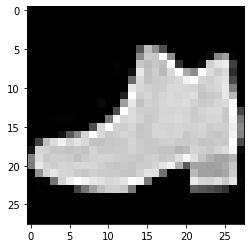

In [16]:
import matplotlib.pyplot as plt 
plt.gray() 
ind = 15
plt.imshow(x.loc[ind].values.reshape(28,28)) 
print ("Label is:", target_encoding[int(y[ind])])
plt.show() 

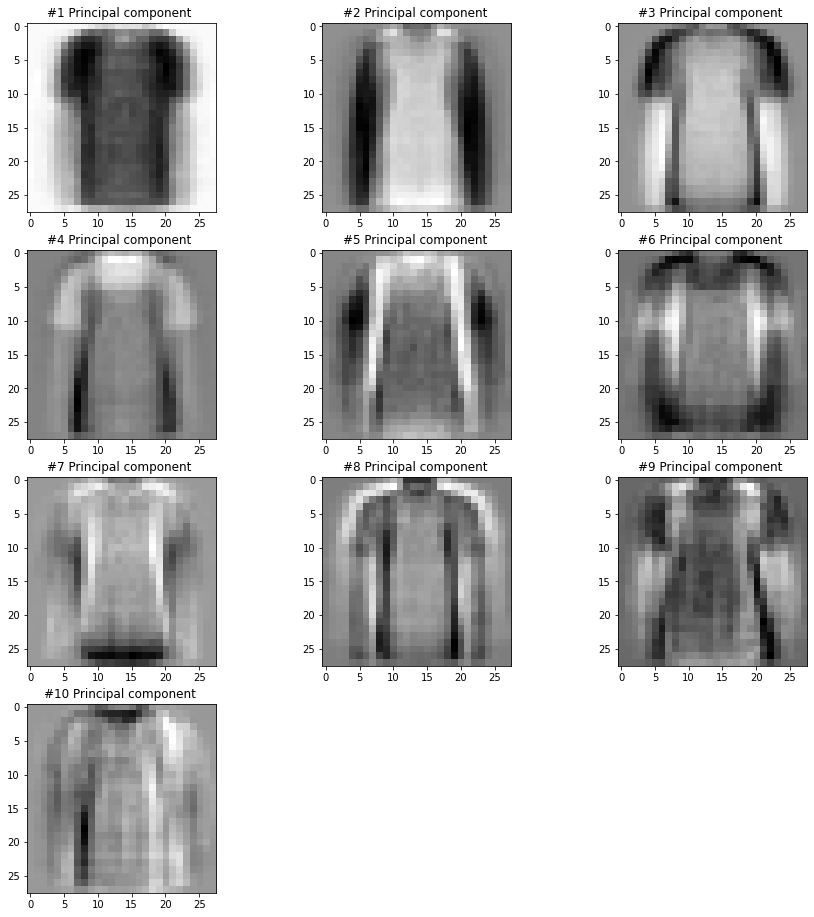

In [88]:
###For three distinct categories or labels, I am choosing T-shirt/top, Dress, Shirt
import math
y_new=[]
index=[]
x_new= pd.DataFrame()

for i in range(0,len(y)):
  if(y[i]== '0' or y[i]== '3' or y[i]== '6'):
    y_new= np.append(y_new,y[i])
    index= np.append(index,i)

for j in index:
  x_new= x_new.append(x.iloc[int(j),:], ignore_index=True)

def eig_val_vec(X):
  
  m, n = X.shape
  mean = X.mean(axis=0)
  X = X - mean 
    
  if m > n:
    C = np.dot(X.T,X) / (m-1) 
    eigen_values, eigen_vectors = np.linalg.eigh(C)
  else:
    C = np.dot(X,X.T) / (m-1) 
    eigen_values, eigen_vectors = np.linalg.eigh(C)
    eigen_vectors = np.dot(X.T, eigen_vectors)
    for i in range(m):
      eigen_vectors[:,i] = eigen_vectors[:, i] / np.linalg.norm(eigen_vectors[:, i])
          
  index = np.argsort(-eigen_values)
  eigen_values = eigen_values[index]
  eigen_vectors = eigen_vectors[:, index]
  
  return eigen_values, eigen_vectors

eigface_eigval, eigface_eigvec= eig_val_vec(x_new)

n_count= 10
rows = math.ceil(n_count/3)
fig = plt.figure(figsize=(15, rows * 4))
for i in range(0, n_count):
  
  plt.subplot(rows, 3, i+1)
  plt.imshow(eigface_eigvec[:, i].reshape(-1, 28), cmap = plt.cm.gray)
  plt.title('#{} Principal component '.format(i+1))


In [89]:
x_new.shape

(299, 784)

In [90]:
eigface_eigvec.shape

(784, 299)

In [58]:
def random_img_reconstruction(N, rand_img_index):
  
  fig, (axes1, axes2)= plt.subplots(1,2, figsize=(7,5)) 
  axes1.imshow(x_new.iloc[rand_img_index,:].values.reshape(-1,28), cmap = plt.cm.gray)
  axes1.set_title('Original image')

  x_new_std= scaler.fit_transform(x_new) # Standardizing the data because the eigface_eigvec variable that I am using is obtained from standardized data

  randimg_eigen_vec= eigface_eigvec[:,0:N] 
  randimg_project= project(randimg_eigen_vec, x_new_std)
  randimg_reconstruct= reconstruct(randimg_eigen_vec, randimg_project)
  randimg_final_reconstruct= scaler.inverse_transform(randimg_reconstruct)  

  axes2.imshow(randimg_final_reconstruct[rand_img_index,:].reshape(-1, 28), cmap = plt.cm.gray)
  axes2.set_title('Reconstructed image using #{} PC '.format(N))
    

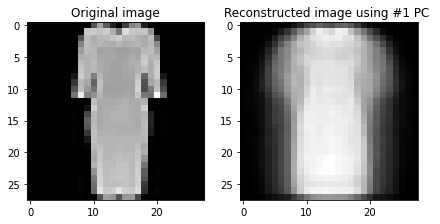

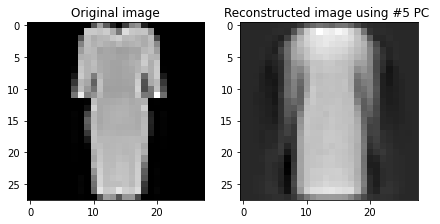

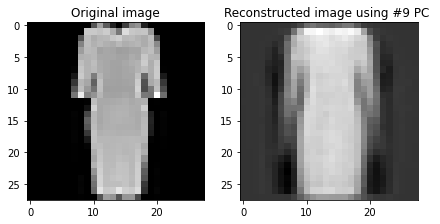

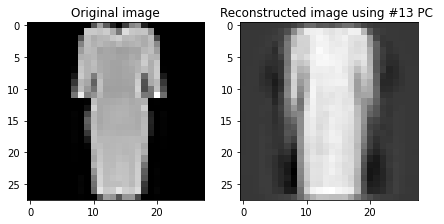

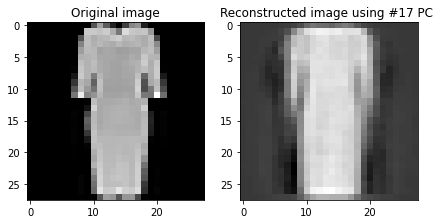

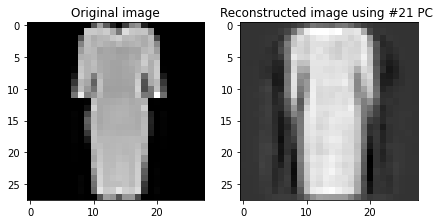

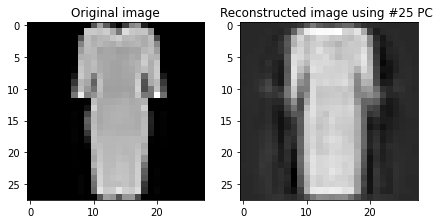

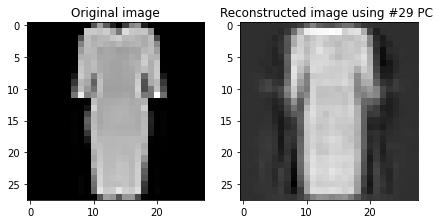

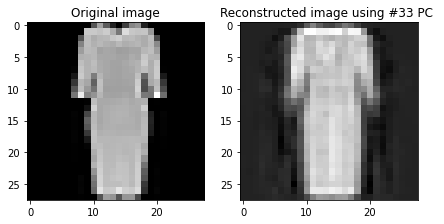

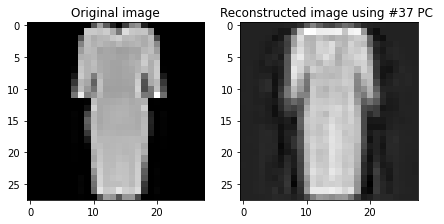

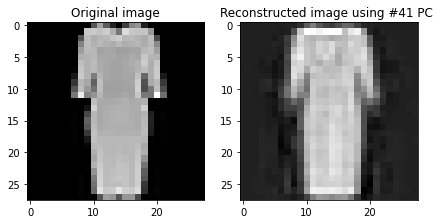

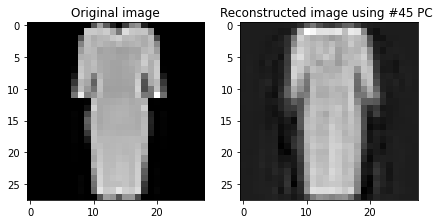

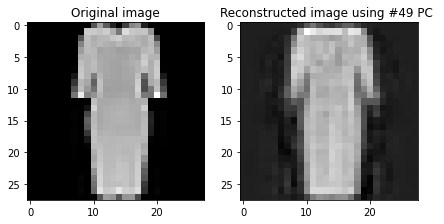

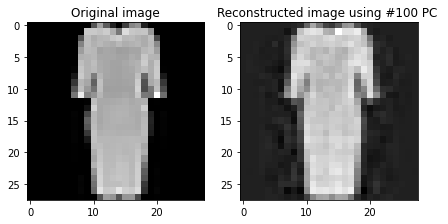

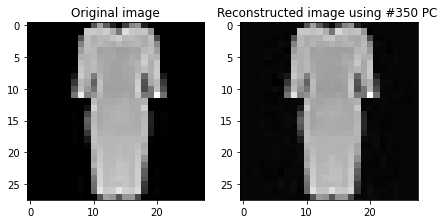

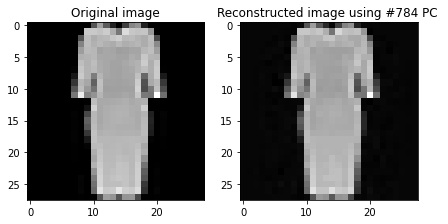

In [84]:
import random

img_index= random.randint(0,len(x_new)-1)

for i in range(1,50,4):
  random_img_reconstruction(i,img_index)

random_img_reconstruction(100,img_index)
random_img_reconstruction(350,img_index)
random_img_reconstruction(784,img_index)

# References

Understanding PCA and SVD:

1. https://towardsdatascience.com/pca-and-svd-explained-with-numpy-5d13b0d2a4d8

2. https://stats.stackexchange.com/questions/134282/relationship-between-svd-and-pca-how-to-use-svd-to-perform-pca

3. https://stats.stackexchange.com/questions/2691/making-sense-of-principal-component-analysis-eigenvectors-eigenvalues

4. https://hadrienj.github.io/posts/Deep-Learning-Book-Series-2.8-Singular-Value-Decomposition/

PCA:

1. Snippets from: https://plot.ly/ipython-notebooks/principal-component-analysis/

2. https://www.value-at-risk.net/principal-component-analysis/

Covid Data:

1. https://www.worldometers.info/coronavirus/

2. https://datahub.io/core/covid-19#resource-time-series-19-covid-combined

